# Utilities

In [1]:
from imports import *

# Assignment 

## Assignment 4.1

In [2]:
#TODO Build a proxi gradient step visualization
#TODO Build a gradient step visualization
train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')
examples = enumerate(train)
_, (x_clean_example, x_noisy_example, labels_example) = next(examples)

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
C:\Users\cgheorgh\AppData\Local\Temp\ipykernel_31432\1658719758.py:3: SyntaxWarning: invalid escape sequence '\D'
  train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')


# Helpers or standalone methods

In [14]:
@staticmethod
def ista(miu:float, shrink:float, no_iterations:int, y:torch.tensor)->torch.tensor:

    # 1.1 Wrap the required definitions in a private function,
    # ... of the members used in both, gradient and proximal steps;
    def _proximal_elements_definition(measurement=y):
        A_def:float = 1.0
        L_def:float = 1.0
        # 1.2 Initialize the unknown signal X to match the measurement shape
        x_def = measurement.clone() 
        return L_def, A_def, x_def
        
    L, A, X = _proximal_elements_definition() # L is required to define the threshold

    # 2.1 Defining shrinkage function
    def shrinkage_fn(current_x, lambd=shrink, measurement=y):
        # 2.2 Incorporating the required step size `miu` into the scalar terms
        W_y = miu * A 
        W_x = 1.0 - (miu * A * A)
        theta = lambd * miu

        # 2.3 ReLU definition wrapped in a private function;
        # Matrix multiplications (@) replaced with scalar multiplications (*)
        u = W_y * measurement + W_x * current_x
        
        # Accommodating the -1 background hint natively
        u_shifted = u + 1.0 
        
        # Using F.relu to cleanly process the maximum condition
        rec = F.relu(u - theta) - F.relu(-u - theta)
        
        # Shift back to the -1 background
        # rec = rec - 1.0

        return rec, (W_y, W_x, theta)

    for iter in range(no_iterations):
        # Update the evolving signal X, while keeping the original measurement y fixed
        X, _ = shrinkage_fn(current_x=X)

    return X

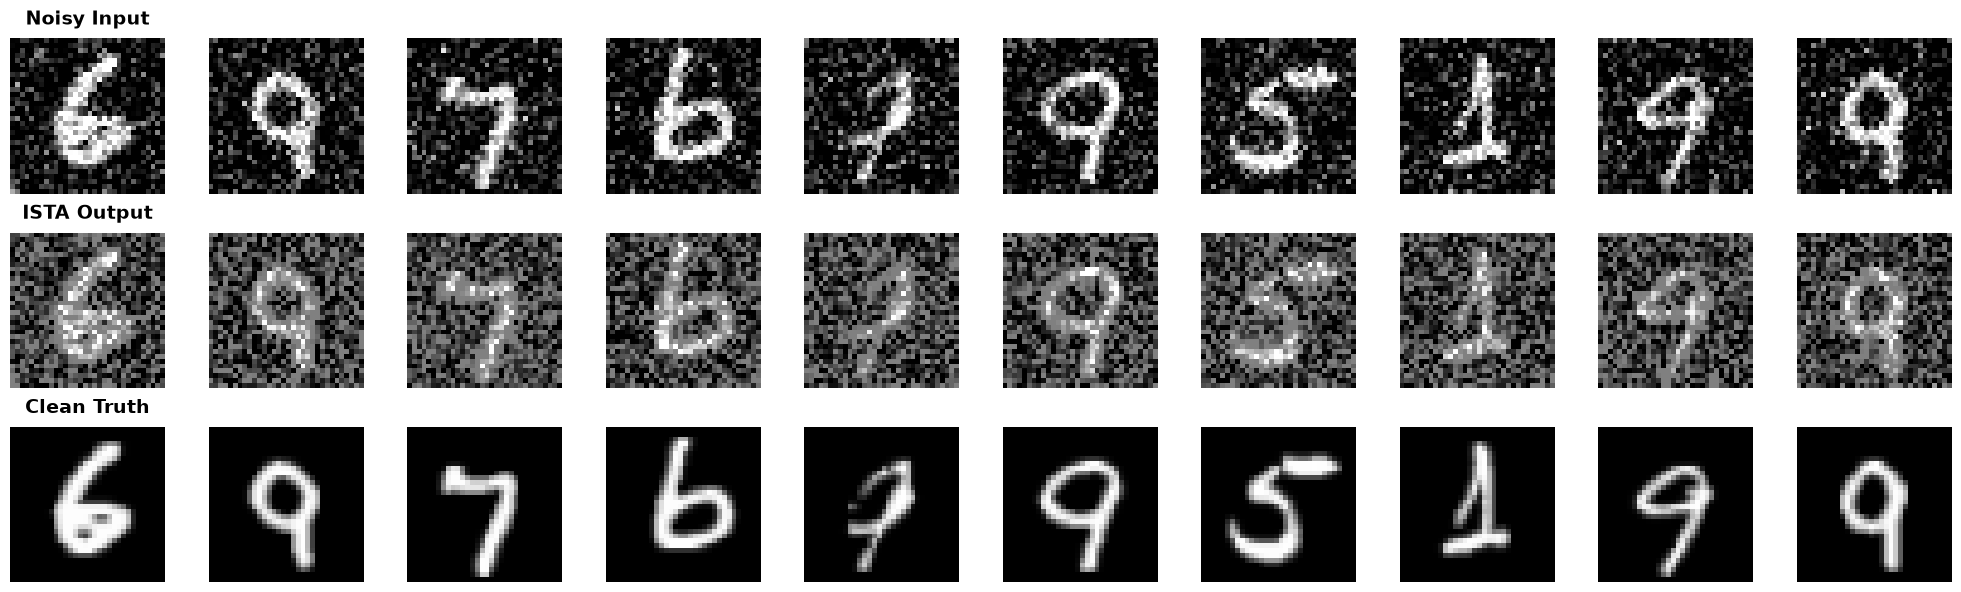

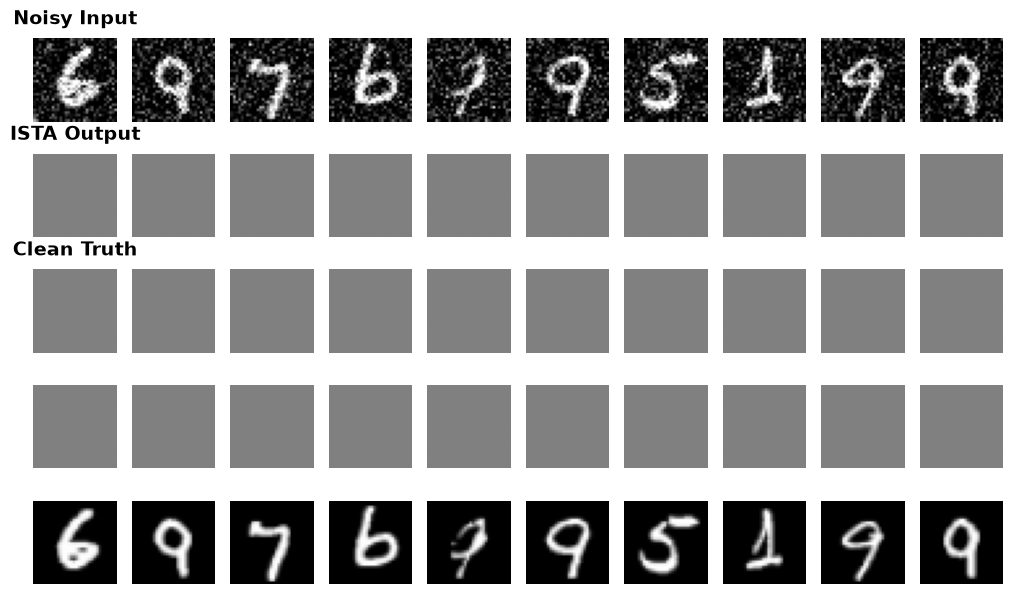

Regular value range of the images is max:1.0 and min:-1.0


In [62]:
# 1. Perform ISTA
ista_reconstructions = ista(miu=5, shrink=0.1, no_iterations=1, y=x_noisy_example)

# 2. Define image-holders variables;
noisy_np = x_noisy_example.squeeze()
recon_np = ista_reconstructions.squeeze()
clean_np = x_clean_example.squeeze()

# Under the suboptimal suit of hyperparameters (that includes both miu/step size and shrinkage/threshold) 
# increasing the number of iterations will do nothing else but to hinder and make the convergence divert even more from 
# the optimal course. The contrary is applicable. Under the optimal pair of hyperparameters, the number of iterations will not change the quality of the solution
# as the convergence was guaranted from the very beginning.
# Based on heuristic experimentation, I discovered that the convergence is mostly influenced by the shrinkage value, which should be lowered until 
# the point the thresholding interval is encapsulated by the measurement matrix interval (e.g., maximum and minimium pixel values fall outside of the thresholding
# limits). Once the optimal shrinking limit was identified corrupting the quality of the solution can be done by adopting a very exagerated value for miu (~ the step-size),
# that is large enough to create a significant departure from the found solution. Not only this effect gets amplified as the miu value grows larger but also
# worsen with increasing the number of iterations that make for an erornous extended walk (e.g., more steps) 

# Assuming x_noisy_example and x_clean_example are already loaded from your dataset
#TODO Document the behavior of the ista based on the parameters;


# Pull tensors back to CPU and convert to numpy for Matplotlib
#TODO Document the function again based on your commentaries
#TODO Dismantled extraneous code commands (e.g., squezee())

# 3. Displaying required results
fig, axes = PLT.subplots(nrows=3, ncols=10, figsize=(20, 6))
for i in range(10):
    # ROW 1: Noisy Measurement (y)
    axes[0, i].imshow(noisy_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Noisy Input", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 2: ISTA Reconstruction (x_K)
    axes[1, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("ISTA Output", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 3: Ground Truth Target (x)
    axes[2, i].imshow(clean_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Clean Truth", fontsize=14, fontweight='bold', pad=10)

PLT.tight_layout()
PLT.show()

# 4. Defining the experiment-setting variable holders and 
# ...displaying experimental results
miu:list = [17, 10, 5, 0.99]
no_iterations:list = [99, 50, 15, 1]
shrink:list = [3, 1.7, 1, 0.1]
fig, axes = PLT.subplots(nrows=5, ncols=10, figsize=(10, 6))
for experiments in range(4):
    ista_reconstructions = ista(miu=miu[experiments], 
                                shrink=miu[experiments], no_iterations=no_iterations[experiments], y=x_noisy_example)
    recon_np = ista_reconstructions.squeeze()

    for i in range(10):
        # ROW 1: Noisy Measurement (y)
        axes[0, i].imshow(noisy_np[i], cmap='gray', vmin=-1, vmax=1)
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Noisy Input", fontsize=14, fontweight='bold', pad=10)

         # ROW 2: ISTA Reconstruction (x_K)
        if experiments == 0:
            axes[1, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
            axes[1, i].axis('off')
            if i == 0: axes[1, i].set_title(f"ISTA Output miu=17, it=99, shrink=3", fontsize=14, fontweight='bold', pad=10)
        elif experiments == 1:
            axes[2, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
            axes[2, i].axis('off')
            if i == 0: axes[1, i].set_title("ISTA Output", fontsize=14, fontweight='bold', pad=10)
        elif experiments == 2:
            axes[3, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
            axes[3, i].axis('off')
            if i == 0: axes[1, i].set_title("ISTA Output", fontsize=14, fontweight='bold', pad=10)
        else:
            axes[4, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
            axes[4, i].axis('off')
            if i == 0: axes[1, i].set_title("ISTA Output", fontsize=14, fontweight='bold', pad=10)


        # ROW 3: Ground Truth Target (x)
        axes[4, i].imshow(clean_np[i], cmap='gray', vmin=-1, vmax=1)
        axes[4, i].axis('off')
        if i == 0: axes[2, i].set_title("Clean Truth", fontsize=14, fontweight='bold', pad=10)

    recon_np = 0

PLT.tight_layout()
PLT.show()

# Informative print;
print("Regular value range of the images is max:{} and min:{}".format(x_clean_example.max(), x_clean_example.min()))